# Обучение
Порядок разделов:

1. Дневные фолды.
2. Базовые модели и сравнение короткого набора признаков с полной матрицей.
3. Подбор LightGBM.
4. Отдельный подбор CatBoost.
5. Внешняя проверка 17–19 апреля.
6. Важность признаков выбранной схемы.
7. Файл ответов.

In [2]:
%matplotlib inline

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings(
    "ignore",
    message="IProgress not found.*",
    category=UserWarning,
    module="tqdm.auto",
)
import optuna
import pandas as pd
from IPython.display import display
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
if not (ROOT / "metric.py").exists():
    nested = ROOT / "bot_detection_challenge"
    if (nested / "metric.py").exists():
        ROOT = nested
    else:
        raise FileNotFoundError("Запускайте ноутбук из папки bot_detection_challenge")

sys.path.insert(0, str(ROOT))
from metric import TARGET_RECALL, precision_at_recall, pr_curve

RANDOM_STATE = 42
SEEDS = (42, 52, 62)
MIN_TRAIN_DAYS = 7
CUT = pd.Timestamp("2026-04-17")
TARGET = "target"
META_COLS = ["cookie_id", "cookie_created_at", "window_start_ts", "window_end_ts", TARGET, "day"]
SHORT_COLS = [
    "dt_median",
    "pointer_x_std",
    "pointer_y_std",
    "night_events_ratio",
    "cookie_age_days",
    "n_events",
    "location_nunique",
    "is_headless_max",
    "search_page_max",
    "event_entropy",
    "item_pop_mean",
]

RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
for stale in ("catboost_importance.csv", "oof_predictions.csv", "oof_scores.csv", "run_info.json"):
    path = RESULTS_DIR / stale
    if path.exists():
        path.unlink()

np.random.seed(RANDOM_STATE)
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12, "axes.unicode_minus": False})

feature_path = ROOT / "features" / "train_features.parquet"
if not feature_path.exists():
    raise FileNotFoundError("Нет features/train_features.parquet. Сначала запустите fe.ipynb")

train_fe = pd.read_parquet(feature_path)
test_fe = pd.read_parquet(ROOT / "features" / "test_features.parquet")
train_fe["window_start_ts"] = pd.to_datetime(train_fe["window_start_ts"])
test_fe["window_start_ts"] = pd.to_datetime(test_fe["window_start_ts"])
train_fe["day"] = train_fe["window_start_ts"].dt.normalize()
test_fe["day"] = test_fe["window_start_ts"].dt.normalize()

feature_cols = json.loads((ROOT / "features" / "feature_columns.json").read_text())
assert all(col in train_fe.columns for col in feature_cols)
assert set(SHORT_COLS) <= set(feature_cols)
assert TARGET in train_fe.columns

internal = train_fe.loc[train_fe["window_start_ts"] < CUT].reset_index(drop=True)
external = train_fe.loc[train_fe["window_start_ts"] >= CUT].reset_index(drop=True)
assert external["day"].dt.strftime("%Y-%m-%d").nunique() == 3
print(f"seed поиска {RANDOM_STATE}, итоговые seed {SEEDS}")
print(f"train {train_fe.shape}, test {test_fe.shape}, признаков {len(feature_cols)}")
print(f"до 17 апреля {len(internal)}, 17–19 апреля {len(external)}")

seed поиска 42, итоговые seed (42, 52, 62)
train (11091, 116), test (4909, 115), признаков 110
до 17 апреля 9140, 17–19 апреля 1951


## 1. Дневные фолды

Внутренняя часть — окна с началом до 17 апреля. Первые 7 дней этой части только учат: на более короткой истории дневная метрика слишком шумная, ботов в дне несколько десятков. Каждый следующий день — отдельная проверка. 17–19 апреля в эти фолды не входят.

Вес cookie обратно пропорционален числу cookie в её дне и затем делится так, чтобы средний вес был 1. Иначе день с 900 cookie перетянет функцию потерь сильнее дня с 600, и модель подстроится под крупные дни.


In [2]:
def expanding_day_folds(df, min_train_days=MIN_TRAIN_DAYS):
    dates = np.array(sorted(df["day"].unique()))
    folds = []
    for pivot in range(min_train_days, len(dates)):
        train_idx = np.flatnonzero(df["day"].isin(dates[:pivot]).to_numpy())
        valid_idx = np.flatnonzero(df["day"].isin([dates[pivot]]).to_numpy())
        folds.append((train_idx, valid_idx, dates[pivot]))
    return folds


def day_weights(df):
    # Вес дня: крупный день не должен перетягивать лосс сильнее малого.
    sizes = df.groupby("day")["cookie_id"].transform("size").astype(float)
    weights = 1.0 / sizes.to_numpy()
    return weights / weights.mean()


folds = expanding_day_folds(internal)
assert folds and all(pd.Timestamp(day) < CUT for _, _, day in folds)
print(f"внутренних фолдов: {len(folds)}")
for i, (tr, va, day) in enumerate(folds, 1):
    print(
        f"  {i}: train до {internal.iloc[tr]['day'].max():%m-%d} ({len(tr)}) | "
        f"valid {pd.Timestamp(day):%m-%d} ({len(va)}, ботов {int(internal.iloc[va][TARGET].sum())})"
    )
print("17–19 апреля в эти фолды не входят")


внутренних фолдов: 4
  1: train до 04-12 (5930) | valid 04-13 (843, ботов 53)
  2: train до 04-13 (6773) | valid 04-14 (826, ботов 70)
  3: train до 04-14 (7599) | valid 04-15 (801, ботов 65)
  4: train до 04-15 (8400) | valid 04-16 (740, ботов 60)
17–19 апреля в эти фолды не входят


## 2. С чего начинаем

На одинаковых дневных фолдах считаем базовые схемы.

Константа ставит всем один score и задаёт нижнюю границу. Логистическая регрессия использует все признаки; пропуски и масштаб обучаются только на тренировочной части каждого фолда.

LightGBM с 100 деревьями сравниваем на полной матрице и на коротком наборе: медиана паузы, разброс курсора, ночная доля, возраст cookie, число событий и локаций, headless-флаг, глубина выдачи, энтропия типов и популярность объявления. Это показывает, добавляет ли остальная история что-то к основным сигналам. Первая колонка итоговой таблицы показывает тот же вывод на внешних днях.

Ранней остановки нет: число деревьев не подбираем по проверочному дню.

In [3]:
def default_lgbm_params(seed):
    return {
        "objective": "binary",
        "n_estimators": 100,
        "verbose": -1,
        "n_jobs": -1,
        "random_state": seed,
    }


def tuned_lgbm_params(seed):
    params = {
        "objective": "binary",
        "subsample_freq": 1,
        "verbose": -1,
        "n_jobs": -1,
        "random_state": seed,
    }
    params.update(study.best_params)
    for key in ("num_leaves", "max_depth", "min_child_samples", "n_estimators"):
        params[key] = int(round(params[key]))
    return params


def predict_constant(tr_df, va_df):
    return np.full(len(va_df), 0.5)


def predict_logreg(tr_df, va_df, columns=None):
    columns = feature_cols if columns is None else columns
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ])
    pipe.fit(tr_df[columns], tr_df[TARGET], clf__sample_weight=day_weights(tr_df))
    return pipe.predict_proba(va_df[columns])[:, 1]


def predict_lgbm(tr_df, va_df, columns, tuned):
    parts = []
    for seed in SEEDS:
        params = tuned_lgbm_params(seed) if tuned else default_lgbm_params(seed)
        model = LGBMClassifier(**params)
        model.fit(tr_df[columns], tr_df[TARGET], sample_weight=day_weights(tr_df))
        parts.append(model.predict_proba(va_df[columns])[:, 1])
    return np.mean(parts, axis=0)


def fixed_catboost_params(seed):
    return {
        "loss_function": "Logloss",
        "iterations": 400,
        "depth": 6,
        "learning_rate": 0.05,
        "l2_leaf_reg": 5,
        "random_seed": seed,
        "allow_writing_files": False,
        "verbose": False,
    }


def tuned_catboost_params(seed):
    params = {
        "loss_function": "Logloss",
        "random_seed": seed,
        "allow_writing_files": False,
        "verbose": False,
    }
    params.update(cat_study.best_params)
    params["iterations"] = int(round(params["iterations"]))
    params["depth"] = int(round(params["depth"]))
    return params


def predict_catboost(tr_df, va_df, columns, tuned):
    parts = []
    for seed in SEEDS:
        params = tuned_catboost_params(seed) if tuned else fixed_catboost_params(seed)
        model = CatBoostClassifier(**params)
        model.fit(tr_df[columns], tr_df[TARGET], sample_weight=day_weights(tr_df))
        parts.append(model.predict_proba(va_df[columns])[:, 1])
    return np.mean(parts, axis=0)


def evaluate(predict_fn):
    day_scores = []
    fold_preds = []
    for tr_idx, va_idx, _ in folds:
        pred = predict_fn(internal.iloc[tr_idx], internal.iloc[va_idx])
        y = internal.iloc[va_idx][TARGET].to_numpy()
        day_scores.append(precision_at_recall(y, pred))
        fold_preds.append(pred)
    ext_pred = predict_fn(internal, external)
    ext_score = precision_at_recall(external[TARGET].to_numpy(), ext_pred)
    return {
        "internal": float(np.mean(day_scores)),
        "external": float(ext_score),
        "day_scores": day_scores,
        "ext_pred": ext_pred,
        "fold_preds": fold_preds,
    }


results = {}
results["константа"] = evaluate(predict_constant)
results["логистическая регрессия"] = evaluate(lambda tr, va: predict_logreg(tr, va, feature_cols))
results["LightGBM, короткий набор"] = evaluate(lambda tr, va: predict_lgbm(tr, va, SHORT_COLS, tuned=False))
results["LightGBM по умолчанию"] = evaluate(lambda tr, va: predict_lgbm(tr, va, feature_cols, tuned=False))

preview = pd.DataFrame({
    "модель": list(results),
    "среднее по внутренним дням": [results[name]["internal"] for name in results],
})
display(preview.round(4))
full_internal = results["LightGBM по умолчанию"]["internal"]
short_internal = results["LightGBM, короткий набор"]["internal"]
if full_internal > short_internal:
    print("На внутренних днях полный набор выше короткого при той же модели.")
else:
    print("На внутренних днях короткий набор не ниже полного при той же модели.")


,модель,среднее по внутренним дням
0,константа,0.0775
1,логистическая регрессия,0.6699
2,"LightGBM, короткий набор",0.6743
3,LightGBM по умолчанию,0.8599


На внутренних днях полный набор выше короткого при той же модели.


## 3. Подбор LightGBM

LightGBM подбирается отдельным поиском. CatBoost в этот поиск не входит, поэтому параметры двух моделей не выбираются по одной и той же случайной вариации.

За 40 испытаний перебираются скорость обучения, число листьев, глубина, минимальный размер листа, доли строк и колонок, две регуляризации и число деревьев. Целевая величина — среднее Precision по внутренним дням до 17 апреля.

Число после `лучшее среднее по внутренним дням` относится к одному запуску с seed 42. В итоговой таблице та же схема усредняется по seed 42, 52 и 62, поэтому значения могут немного различаться.

In [4]:
def objective(trial):
    max_depth = trial.suggest_int("max_depth", 4, 8)
    params = {
        "objective": "binary",
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        "max_depth": max_depth,
        "num_leaves": trial.suggest_int("num_leaves", 8, min(127, 2 ** max_depth - 1)),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "verbose": -1,
        "n_jobs": -1,
        "random_state": RANDOM_STATE,
    }
    scores = []
    for tr_idx, va_idx, _ in folds:
        tr = internal.iloc[tr_idx]
        va = internal.iloc[va_idx]
        model = LGBMClassifier(**params)
        model.fit(tr[feature_cols], tr[TARGET], sample_weight=day_weights(tr))
        pred = model.predict_proba(va[feature_cols])[:, 1]
        scores.append(precision_at_recall(va[TARGET].to_numpy(), pred))
    return float(np.mean(scores))


# Дни 17–19 апреля не входят в objective: по ним параметры проверяются один раз после поиска.
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=40, show_progress_bar=False)
print(f"испытаний {len(study.trials)}, лучшее среднее по внутренним дням: {study.best_value:.4f}")
print(study.best_params)
study.trials_dataframe().to_csv(RESULTS_DIR / "optuna_trials.csv", index=False)


испытаний 40, лучшее среднее по внутренним дням: 0.8827
{'max_depth': 8, 'learning_rate': 0.033686403295555147, 'num_leaves': 110, 'min_child_samples': 99, 'subsample': 0.9691272068386685, 'colsample_bytree': 0.6456488574489608, 'reg_alpha': 0.02967552721667268, 'reg_lambda': 0.25067760880662976, 'n_estimators': 315}


## 4. Подбор CatBoost

CatBoost подбирается отдельно на тех же внутренних днях до 17 апреля. В поиске 15 испытаний и четыре параметра: число деревьев, глубина, скорость обучения и `l2_leaf_reg`.

В таблице сохраняется и фиксированный вариант до поиска: 400 деревьев, глубина 6, шаг 0.05 и `l2_leaf_reg` 5. Это нужно, чтобы увидеть, помог ли подбор на внешних днях.

Число после `лучшее среднее по внутренним дням` получено на одном seed 42. В таблице CatBoost запускается с тремя seed, поэтому итоговая строка может быть немного ниже или выше.

In [5]:
def cat_objective(trial):
    params = {
        "loss_function": "Logloss",
        "iterations": trial.suggest_int("iterations", 200, 600),
        "depth": trial.suggest_int("depth", 4, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "random_seed": RANDOM_STATE,
        "allow_writing_files": False,
        "verbose": False,
    }
    scores = []
    for tr_idx, va_idx, _ in folds:
        tr = internal.iloc[tr_idx]
        va = internal.iloc[va_idx]
        model = CatBoostClassifier(**params)
        model.fit(tr[feature_cols], tr[TARGET], sample_weight=day_weights(tr))
        pred = model.predict_proba(va[feature_cols])[:, 1]
        scores.append(precision_at_recall(va[TARGET].to_numpy(), pred))
    return float(np.mean(scores))


# Дни 17–19 апреля не входят в objective: по ним параметры проверяются один раз после поиска.
cat_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
cat_study.optimize(cat_objective, n_trials=15, show_progress_bar=False)
print(f"испытаний {len(cat_study.trials)}, лучшее среднее по внутренним дням: {cat_study.best_value:.4f}")
print(cat_study.best_params)
cat_study.trials_dataframe().to_csv(RESULTS_DIR / "optuna_catboost_trials.csv", index=False)


испытаний 15, лучшее среднее по внутренним дням: 0.8799
{'iterations': 587, 'depth': 5, 'learning_rate': 0.021137825040694082, 'l2_leaf_reg': 7.298875089294377}


## 5. Проверка на 17–19 апреля

Каждую схему один раз обучаем на всех окнах до 17 апреля и проверяем на 17, 18 и 19 апреля вместе. Эти дни не участвовали в поиске параметров.

Среднее двух вероятностей — не новая модель, а полусумма score подобранных LightGBM и CatBoost для каждой cookie. В таблице оно стоит рядом с одиночными моделями, чтобы проверить, даёт ли смешивание устойчивый выигрыш.

Победителя выбираем по внешней метрике; при точном равенстве используем среднюю внутреннюю метрику. Если разница составляет одну-две cookie, это слабое преимущество, и его нужно читать вместе с числом ботов на внешних днях.

PR-кривая ниже строится только для схемы, которая будет использована при создании файла.

,модель,17–19 апреля,среднее по внутренним дням
0,константа,0.0820,0.0775
1,логистическая регрессия,0.5283,0.6699
2,"LightGBM, короткий набор",0.5864,0.6743
3,LightGBM по умолчанию,0.7619,0.8599
4,LightGBM после Optuna,0.7808,0.8713
5,CatBoost до подбора,0.8116,0.8717
6,CatBoost после Optuna,0.7724,0.8787
7,среднее двух вероятностей,0.8129,0.8741


в файл: среднее двух вероятностей


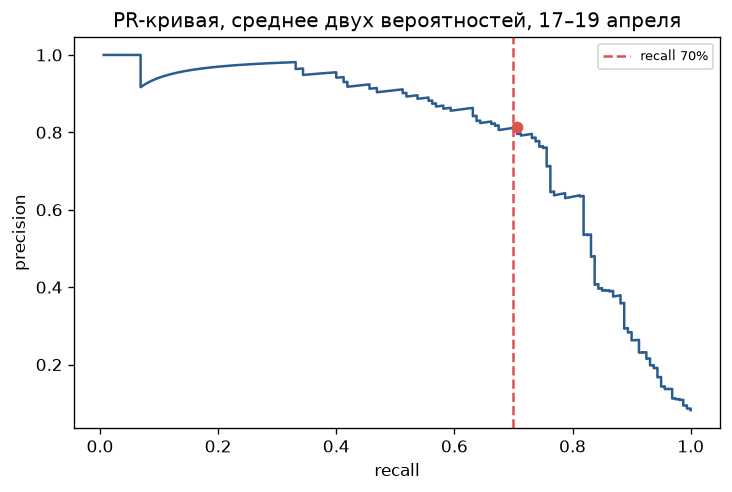

In [ ]:
results["LightGBM после Optuna"] = evaluate(lambda tr, va: predict_lgbm(tr, va, feature_cols, tuned=True))
results["CatBoost до подбора"] = evaluate(lambda tr, va: predict_catboost(tr, va, feature_cols, tuned=False))
results["CatBoost после Optuna"] = evaluate(lambda tr, va: predict_catboost(tr, va, feature_cols, tuned=True))

tuned = results["LightGBM после Optuna"]
cat = results["CatBoost после Optuna"]
blend_days = []
for (_, va_idx, _), p1, p2 in zip(folds, tuned["fold_preds"], cat["fold_preds"]):
    pred = 0.5 * (p1 + p2)
    blend_days.append(precision_at_recall(internal.iloc[va_idx][TARGET].to_numpy(), pred))
blend_ext = 0.5 * (tuned["ext_pred"] + cat["ext_pred"])
results["среднее двух вероятностей"] = {
    "internal": float(np.mean(blend_days)),
    "external": float(precision_at_recall(external[TARGET].to_numpy(), blend_ext)),
    "day_scores": blend_days,
    "ext_pred": blend_ext,
    "fold_preds": [0.5 * (p1 + p2) for p1, p2 in zip(tuned["fold_preds"], cat["fold_preds"])],
}

order = [
    "константа",
    "логистическая регрессия",
    "LightGBM, короткий набор",
    "LightGBM по умолчанию",
    "LightGBM после Optuna",
    "CatBoost до подбора",
    "CatBoost после Optuna",
    "среднее двух вероятностей",
]
comparison = pd.DataFrame({
    "модель": order,
    "17–19 апреля": [results[name]["external"] for name in order],
    "среднее по внутренним дням": [results[name]["internal"] for name in order],
})
comparison.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)

winner = max(order, key=lambda name: (results[name]["external"], results[name]["internal"]))
print("в файл:", winner)
if winner == "среднее двух вероятностей":
    cat_score = results["CatBoost до подбора"]["external"]
    blend_score = results[winner]["external"]
    print(f"разница со стационарным CatBoost: {blend_score - cat_score:+.4f}")

# PR-кривая относится к той же схеме, которая пойдёт в submission.csv.
y_ext = external[TARGET].to_numpy()
prec, rec = pr_curve(y_ext, results[winner]["ext_pred"])
fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.plot(rec, prec, color="#2b5c8f")
ax.axvline(TARGET_RECALL, color="#d9534f", ls="--", label="recall 70%")
ok = rec >= TARGET_RECALL
if ok.any():
    best_i = int(np.argmax(np.where(ok, prec, -1)))
    ax.scatter([rec[best_i]], [prec[best_i]], color="#d9534f", zorder=3)
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title(f"PR-кривая, {winner}, 17–19 апреля")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "pr_curve.png", bbox_inches="tight")
plt.show()

## 6. Что двигает метрику

График строится для схемы из файла, не для соседней строки таблицы. Если в файл записано среднее двух вероятностей, перемешивается столбец сразу у обеих моделей и заново считается их полусумма. Если записан один CatBoost или один LightGBM, вторая модель в график не входит.

Модель учится только на окнах до 17 апреля, столбец перемешивается на 17–19 апреля. Падение — это насколько портится Precision при Recall ≥ 70%.


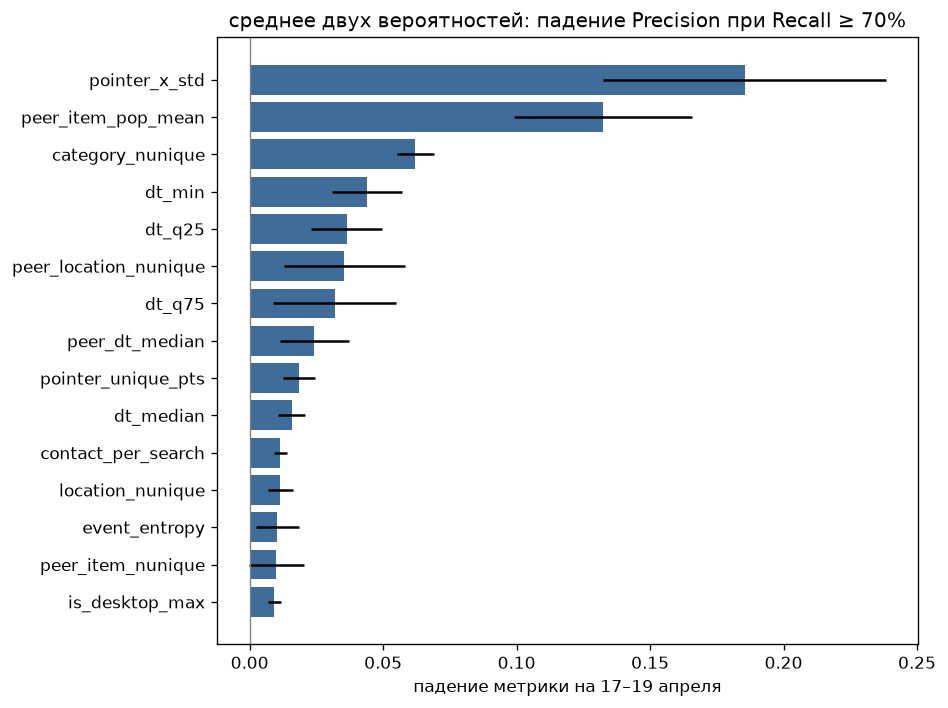

,feature,drop_mean,drop_std
0,pointer_x_std,0.1854,0.0530
1,peer_item_pop_mean,0.1325,0.0333
2,category_nunique,0.0621,0.0069
3,dt_min,0.0439,0.0130
4,dt_q25,0.0363,0.0133
5,peer_location_nunique,0.0354,0.0227
6,dt_q75,0.0318,0.0230
7,peer_dt_median,0.0242,0.0129
8,pointer_unique_pts,0.0186,0.0060
9,dt_median,0.0158,0.0050


In [7]:
def fit_predict(kind, tr_df):
    columns = SHORT_COLS if kind == "short" else feature_cols
    if kind == "constant":
        return columns, lambda frame: np.full(len(frame), 0.5)
    if kind == "logreg":
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
        ])
        pipe.fit(tr_df[columns], tr_df[TARGET], clf__sample_weight=day_weights(tr_df))
        return columns, lambda frame: pipe.predict_proba(frame[columns])[:, 1]
    if kind in ("lgbm_default", "short", "lgbm_tuned"):
        models = []
        for seed in SEEDS:
            params = tuned_lgbm_params(seed) if kind == "lgbm_tuned" else default_lgbm_params(seed)
            model = LGBMClassifier(**params)
            model.fit(tr_df[columns], tr_df[TARGET], sample_weight=day_weights(tr_df))
            models.append(model)
        return columns, lambda frame: np.mean([model.predict_proba(frame[columns])[:, 1] for model in models], axis=0)
    if kind in ("catboost", "catboost_tuned"):
        models = []
        for seed in SEEDS:
            params = tuned_catboost_params(seed) if kind == "catboost_tuned" else fixed_catboost_params(seed)
            model = CatBoostClassifier(**params)
            model.fit(tr_df[columns], tr_df[TARGET], sample_weight=day_weights(tr_df))
            models.append(model)
        return columns, lambda frame: np.mean([model.predict_proba(frame[columns])[:, 1] for model in models], axis=0)
    if kind == "blend":
        _, left = fit_predict("lgbm_tuned", tr_df)
        _, right = fit_predict("catboost_tuned", tr_df)
        return feature_cols, lambda frame: 0.5 * (left(frame) + right(frame))
    raise KeyError(kind)


KIND = {
    "константа": "constant",
    "логистическая регрессия": "logreg",
    "LightGBM, короткий набор": "short",
    "LightGBM по умолчанию": "lgbm_default",
    "LightGBM после Optuna": "lgbm_tuned",
    "CatBoost до подбора": "catboost",
    "CatBoost после Optuna": "catboost_tuned",
    "среднее двух вероятностей": "blend",
}

imp_columns, imp_predict = fit_predict(KIND[winner], internal)
x_hold = external[imp_columns].copy()
y_hold = external[TARGET].to_numpy()
base_score = precision_at_recall(y_hold, imp_predict(x_hold))
rng = np.random.default_rng(RANDOM_STATE)
rows = []
for column in imp_columns:
    original = x_hold[column].to_numpy().copy()
    drops = []
    for _ in range(4):
        x_hold[column] = rng.permutation(original)
        drops.append(base_score - precision_at_recall(y_hold, imp_predict(x_hold)))
    x_hold[column] = original
    rows.append((column, float(np.mean(drops)), float(np.std(drops))))

importance = (
    pd.DataFrame(rows, columns=["feature", "drop_mean", "drop_std"])
    .sort_values("drop_mean", ascending=False)
    .reset_index(drop=True)
)
importance.to_csv(RESULTS_DIR / "feature_importance.csv", index=False)

top = importance.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top["feature"], top["drop_mean"], xerr=top["drop_std"], color="#2b5c8f", alpha=0.9)
ax.axvline(0, color="gray", lw=0.8)
ax.set_title(f"{winner}: падение Precision при Recall ≥ 70%")
ax.set_xlabel("падение метрики на 17–19 апреля")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "feature_importance.png", bbox_inches="tight")
plt.show()
display(importance.head(10).round(4))


## 7. Файл ответов

Выбранную схему учим заново на всём train, включая 17–19 апреля, и считаем score для test. Три seed усредняются внутри схемы. Если выбрано среднее двух вероятностей, усредняются и seed, и две модели: сначала три запуска LightGBM, три запуска CatBoost, потом полусумма двух score.


In [ ]:
display(comparison.round(4))

sub_columns, sub_predict = fit_predict(KIND[winner], train_fe)
test_score = sub_predict(test_fe)
raw_test = pd.read_csv(ROOT / "data" / "test.csv", usecols=["cookie_id"])
submission = pd.DataFrame({
    "cookie_id": test_fe["cookie_id"].astype(str),
    "score": np.asarray(test_score, dtype=float),
})
assert list(submission.columns) == ["cookie_id", "score"]
assert len(submission) == 4909
assert submission["cookie_id"].tolist() == raw_test["cookie_id"].astype(str).tolist()
assert submission["cookie_id"].is_unique
assert submission["score"].notna().all()
assert submission["score"].between(0, 1).all()
submission.to_csv(ROOT / "submission.csv", index=False)
print(
    f"{winner}: {len(submission)} строк, порядок как в data/test.csv, "
    f"пропусков нет, score от {submission['score'].min():.4f} до {submission['score'].max():.4f}"
)

среднее двух вероятностей: 4909 строк, score от 0.0007 до 0.9967
